**Phase 1 : Chargement et audit des données**

In [13]:
# Impoort des librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Afficher toutes les colonnes dans les résultats
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

In [14]:
# Chargement du dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [15]:
# Dimension du dataset
print("Audit initial du dataset Telco Customer Churn")
print(f"Dimensions : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")

Audit initial du dataset Telco Customer Churn
Dimensions : 7,043 lignes × 21 colonnes


In [16]:
# Vérification des types de données
print("\nTypes de données :")
print(df.dtypes)


Types de données :
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [18]:
# Recherche des valeurs manquantes
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]

print("\nValeurs manquantes :")
if missing_values.empty:
    print("Aucune valeur manquante détectée.")
else:
    print(missing_values)


Valeurs manquantes :
Aucune valeur manquante détectée.


In [19]:
# Recherche des doublons
duplicate_count = df.duplicated().sum()

print("\nDoublons :")
print(f"{duplicate_count:,} ligne(s) en doublon")


Doublons :
0 ligne(s) en doublon


In [20]:
# Vérification de la variable cible
print("\nDistribution de Churn :")
print(df["Churn"].value_counts())

print("\nProportion de Churn :")
print((df["Churn"].value_counts(normalize=True) * 100).round(2))


Distribution de Churn :
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Proportion de Churn :
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


In [21]:
# Nombre de valeurs uniques pour les variables catégorielles
categorical_columns = df.select_dtypes(include="object").columns

print("\nVariables catégorielles :")

for column in categorical_columns:
    unique_values = df[column].dropna().unique()

    print(f"\n{column} : {len(unique_values)} valeur(s) unique(s)")

    # Afficher les modalités lorsque leur nombre reste raisonnable
    if len(unique_values) <= 10:
        print(f"Modalités : {list(unique_values)}")


Variables catégorielles :

customerID : 7043 valeur(s) unique(s)

gender : 2 valeur(s) unique(s)
Modalités : ['Female', 'Male']

Partner : 2 valeur(s) unique(s)
Modalités : ['Yes', 'No']

Dependents : 2 valeur(s) unique(s)
Modalités : ['No', 'Yes']

PhoneService : 2 valeur(s) unique(s)
Modalités : ['No', 'Yes']

MultipleLines : 3 valeur(s) unique(s)
Modalités : ['No phone service', 'No', 'Yes']

InternetService : 3 valeur(s) unique(s)
Modalités : ['DSL', 'Fiber optic', 'No']

OnlineSecurity : 3 valeur(s) unique(s)
Modalités : ['No', 'Yes', 'No internet service']

OnlineBackup : 3 valeur(s) unique(s)
Modalités : ['Yes', 'No', 'No internet service']

DeviceProtection : 3 valeur(s) unique(s)
Modalités : ['No', 'Yes', 'No internet service']

TechSupport : 3 valeur(s) unique(s)
Modalités : ['No', 'Yes', 'No internet service']

StreamingTV : 3 valeur(s) unique(s)
Modalités : ['No', 'Yes', 'No internet service']

StreamingMovies : 3 valeur(s) unique(s)
Modalités : ['No', 'Yes', 'No internet 

In [22]:
# Statistiques descriptives des variables numériques
print("\nStatistiques descriptives :")
print(df.describe())


Statistiques descriptives :
       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


In [23]:
# TotalCharges nécessite une vérification particulière car cette colonne
# peut être importée comme texte et contenir des valeurs vides.
print("\nVérification de TotalCharges :")
print(f"Type actuel : {df['TotalCharges'].dtype}")


Vérification de TotalCharges :
Type actuel : object


In [24]:
# Recherche des chaînes vides ou composées uniquement d'espaces
empty_total_charges = df["TotalCharges"].astype(str).str.strip().eq(" ").sum()
print(f"Valeurs vides détectées : {empty_total_charges}")

Valeurs vides détectées : 0


In [26]:
# Conversion temporaire en numérique pour identifier les valeurs problématiques
total_charges_numeric = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

invalid_total_charges = total_charges_numeric.isna().sum()

print(f"Valeurs non convertibles en numérique : {invalid_total_charges}")

if invalid_total_charges > 0:
    print("\nExemple de lignes concernées :")

    invalid_rows = df.loc[
        total_charges_numeric.isna(),
        ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]
    ]

    print(invalid_rows.head())

Valeurs non convertibles en numérique : 11

Exemple de lignes concernées :
      customerID  tenure  MonthlyCharges TotalCharges
488   4472-LVYGI       0           52.55             
753   3115-CZMZD       0           20.25             
936   5709-LVOEQ       0           80.85             
1082  4367-NUYAO       0           25.75             
1340  1371-DWPAZ       0           56.05             


In [27]:
# Synthèse de l'audit
print("\nSynthèse de l'audit")

if duplicate_count == 0:
    print("✓ Aucun doublon détecté")
else:
    print(f"⚠ {duplicate_count:,} doublon(s) détecté(s)")

if missing_values.empty:
    print("✓ Aucune valeur manquante détectée")
else:
    print("⚠ Des valeurs manquantes doivent être analysées")

if invalid_total_charges == 0:
    print("✓ TotalCharges est correctement convertible")
else:
    print(f"⚠ {invalid_total_charges} valeur(s) problématique(s) dans TotalCharges")


Synthèse de l'audit
✓ Aucun doublon détecté
✓ Aucune valeur manquante détectée
⚠ 11 valeur(s) problématique(s) dans TotalCharges


In [29]:
# Repérer les lignes où TotalCharges ne peut pas être converti en nombre
invalid_mask = total_charges_numeric.isna()
invalid_data = df.loc[invalid_mask].copy()

print("Analyse des lignes présentant un problème dans TotalCharges")
print(f"Nombre de lignes concernées : {len(invalid_data)}")

Analyse des lignes présentant un problème dans TotalCharges
Nombre de lignes concernées : 11


In [30]:
# Afficher les informations utiles pour comprendre ces lignes
pd.set_option("display.max_rows", None)

print("\nClients concernés :")
print(
    invalid_data[
        ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
    ]
)


Clients concernés :
      customerID  tenure  MonthlyCharges TotalCharges Churn
488   4472-LVYGI       0           52.55                 No
753   3115-CZMZD       0           20.25                 No
936   5709-LVOEQ       0           80.85                 No
1082  4367-NUYAO       0           25.75                 No
1340  1371-DWPAZ       0           56.05                 No
3331  7644-OMVMY       0           19.85                 No
3826  3213-VVOLG       0           25.35                 No
4380  2520-SGTTA       0           20.00                 No
5218  2923-ARZLG       0           19.70                 No
6670  4075-WKNIU       0           73.35                 No
6754  2775-SEFEE       0           61.90                 No


In [31]:
# Examiner le profil de ces clients
print("\nProfil des clients concernés")

print("\nAncienneté (en mois) :")
print(invalid_data["tenure"].describe())

print("\nRépartition du Churn :")
print(invalid_data["Churn"].value_counts())

print("\nCharges mensuelles :")
print(invalid_data["MonthlyCharges"].describe())


Profil des clients concernés

Ancienneté (en mois) :
count    11.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
Name: tenure, dtype: float64

Répartition du Churn :
Churn
No    11
Name: count, dtype: int64

Charges mensuelles :
count    11.000000
mean     41.418182
std      23.831484
min      19.700000
25%      20.125000
50%      25.750000
75%      58.975000
max      80.850000
Name: MonthlyCharges, dtype: float64


In [32]:
# Vérifier précisément ce qui se trouve dans TotalCharges
print("\nValeurs brutes de TotalCharges")

for index in invalid_data.index:
    valeur = df.loc[index, "TotalCharges"]

    print(
        f"Ligne {index} | "
        f"valeur brute : {repr(valeur)} | "
        f"valeur après suppression des espaces : {repr(str(valeur).strip())}"
    )


Valeurs brutes de TotalCharges
Ligne 488 | valeur brute : ' ' | valeur après suppression des espaces : ''
Ligne 753 | valeur brute : ' ' | valeur après suppression des espaces : ''
Ligne 936 | valeur brute : ' ' | valeur après suppression des espaces : ''
Ligne 1082 | valeur brute : ' ' | valeur après suppression des espaces : ''
Ligne 1340 | valeur brute : ' ' | valeur après suppression des espaces : ''
Ligne 3331 | valeur brute : ' ' | valeur après suppression des espaces : ''
Ligne 3826 | valeur brute : ' ' | valeur après suppression des espaces : ''
Ligne 4380 | valeur brute : ' ' | valeur après suppression des espaces : ''
Ligne 5218 | valeur brute : ' ' | valeur après suppression des espaces : ''
Ligne 6670 | valeur brute : ' ' | valeur après suppression des espaces : ''
Ligne 6754 | valeur brute : ' ' | valeur après suppression des espaces : ''


**Phase 2 : Data Cleaning :** 

In [33]:
# On travaille sur une copie pour conserver le dataset original
df_clean = df.copy()

In [34]:
# Nettoyage de TotalCharges
print("\n1. Nettoyage de TotalCharges")

print(f"Type avant nettoyage : {df_clean['TotalCharges'].dtype}")


1. Nettoyage de TotalCharges
Type avant nettoyage : object


In [35]:
# Les espaces correspondent aux nouveaux clients qui n'ont pas encore
# d'historique de facturation. Leur ancienneté est nulle.
df_clean["TotalCharges"] = df_clean["TotalCharges"].replace(" ", "0")

# Conversion en valeur numérique
df_clean["TotalCharges"] = pd.to_numeric(
    df_clean["TotalCharges"],
    errors="coerce"
)

invalid_total_charges = df_clean["TotalCharges"].isna().sum()

print(f"Type après conversion : {df_clean['TotalCharges'].dtype}")
print(f"Valeurs non convertibles : {invalid_total_charges}")


Type après conversion : float64
Valeurs non convertibles : 0


In [36]:
# Transformation de la variable cible
print("\n2. Transformation de Churn")

print(f"Valeurs initiales : {df_clean['Churn'].unique()}")

df_clean["Churn"] = df_clean["Churn"].map({
    "Yes": 1,
    "No": 0
})

print(f"Valeurs après transformation : {df_clean['Churn'].unique()}")
print("Répartition de la variable cible :")
print(df_clean["Churn"].value_counts())


2. Transformation de Churn
Valeurs initiales : ['No' 'Yes']
Valeurs après transformation : [0 1]
Répartition de la variable cible :
Churn
0    5174
1    1869
Name: count, dtype: int64


In [37]:
# Transformation des variables binaires Yes/No
print("\n3. Transformation des variables binaires")

yes_no_columns = [
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

for column in yes_no_columns:
    if column in df_clean.columns:
        valeurs = set(df_clean[column].dropna().unique())

        # On transforme uniquement les colonnes qui contiennent
        # exclusivement les modalités Yes et No.
        if valeurs.issubset({"Yes", "No"}):
            df_clean[column] = df_clean[column].map({
                "Yes": 1,
                "No": 0
            })

            print(f"{column} : Yes/No → 1/0")


3. Transformation des variables binaires
Partner : Yes/No → 1/0
Dependents : Yes/No → 1/0
PhoneService : Yes/No → 1/0
PaperlessBilling : Yes/No → 1/0


In [38]:
# Vérification des types après nettoyage
print("\n4. Vérification des types de données")

print(df_clean.dtypes)


4. Vérification des types de données
customerID           object
gender               object
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling      int64
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object


In [39]:
# Contrôle de qualité
print("\n5. Contrôle de qualité")

missing_values = df_clean.isnull().sum().sum()
duplicate_count = df_clean.duplicated().sum()

print(f"Valeurs manquantes : {missing_values}")
print(f"Doublons : {duplicate_count}")


5. Contrôle de qualité
Valeurs manquantes : 0
Doublons : 0


In [40]:
# Vérification de quelques règles simples de cohérence
print(f"Ancienneté positive ou nulle : {(df_clean['tenure'] >= 0).all()}")
print(f"Charges mensuelles positives ou nulles : {(df_clean['MonthlyCharges'] >= 0).all()}")
print(f"Charges totales positives ou nulles : {(df_clean['TotalCharges'] >= 0).all()}")

Ancienneté positive ou nulle : True
Charges mensuelles positives ou nulles : True
Charges totales positives ou nulles : True


In [41]:
# Aperçu des données après nettoyage
print("\nAperçu des données nettoyées :")
print(df_clean.head())


Aperçu des données nettoyées :
   customerID  gender  SeniorCitizen  Partner  Dependents  tenure  \
0  7590-VHVEG  Female              0        1           0       1   
1  5575-GNVDE    Male              0        0           0      34   
2  3668-QPYBK    Male              0        0           0       2   
3  7795-CFOCW    Male              0        0           0      45   
4  9237-HQITU  Female              0        0           0       2   

   PhoneService     MultipleLines InternetService OnlineSecurity OnlineBackup  \
0             0  No phone service             DSL             No          Yes   
1             1                No             DSL            Yes           No   
2             1                No             DSL            Yes          Yes   
3             0  No phone service             DSL            Yes           No   
4             1                No     Fiber optic             No           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        

In [43]:
# Vérification finale des types de données
print("Types de données après nettoyage :")
print(df_clean.dtypes)

Types de données après nettoyage :
customerID           object
gender               object
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling      int64
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object


In [44]:
# Identifier les variables catégorielles qui sont encore au format texte
object_columns = df_clean.select_dtypes(include="object").columns.tolist()

print("\nVariables catégorielles restantes :")

for column in object_columns:
    print(f"\n{column}")
    print(f"Nombre de modalités : {df_clean[column].nunique()}")
    print(f"Modalités : {df_clean[column].unique()}")


Variables catégorielles restantes :

customerID
Nombre de modalités : 7043
Modalités : ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

gender
Nombre de modalités : 2
Modalités : ['Female' 'Male']

MultipleLines
Nombre de modalités : 3
Modalités : ['No phone service' 'No' 'Yes']

InternetService
Nombre de modalités : 3
Modalités : ['DSL' 'Fiber optic' 'No']

OnlineSecurity
Nombre de modalités : 3
Modalités : ['No' 'Yes' 'No internet service']

OnlineBackup
Nombre de modalités : 3
Modalités : ['Yes' 'No' 'No internet service']

DeviceProtection
Nombre de modalités : 3
Modalités : ['No' 'Yes' 'No internet service']

TechSupport
Nombre de modalités : 3
Modalités : ['No' 'Yes' 'No internet service']

StreamingTV
Nombre de modalités : 3
Modalités : ['No' 'Yes' 'No internet service']

StreamingMovies
Nombre de modalités : 3
Modalités : ['No' 'Yes' 'No internet service']

Contract
Nombre de modalités : 3
Modalités : ['Month-to-month' 'One year' 'Two year'

In [45]:
# Identifier les variables numériques
numeric_columns = df_clean.select_dtypes(include="number").columns.tolist()

print("\nVariables numériques :")
print(numeric_columns)


Variables numériques :
['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [46]:
# Vérification de la variable cible
print("\nVérification de Churn")

print(f"Valeurs présentes : {df_clean['Churn'].unique()}")
print("Répartition :")
print(df_clean["Churn"].value_counts())

taux_churn = df_clean["Churn"].mean() * 100
print(f"Taux de churn : {taux_churn:.2f} %")


Vérification de Churn
Valeurs présentes : [0 1]
Répartition :
Churn
0    5174
1    1869
Name: count, dtype: int64
Taux de churn : 26.54 %


In [47]:
# Vérification de TotalCharges après conversion
print("\nVérification de TotalCharges")

print(f"Type : {df_clean['TotalCharges'].dtype}")
print(f"Minimum : {df_clean['TotalCharges'].min():.2f}")
print(f"Maximum : {df_clean['TotalCharges'].max():.2f}")
print(f"Moyenne : {df_clean['TotalCharges'].mean():.2f}")


Vérification de TotalCharges
Type : float64
Minimum : 0.00
Maximum : 8684.80
Moyenne : 2279.73


In [48]:
# Vérification des nouveaux clients sans historique de facturation
nouveaux_clients = (
    (df_clean["tenure"] == 0) &
    (df_clean["TotalCharges"] == 0)
).sum()

print(
    f"Clients avec une ancienneté de 0 mois et "
    f"TotalCharges égal à 0 : {nouveaux_clients}"
)

Clients avec une ancienneté de 0 mois et TotalCharges égal à 0 : 11


In [49]:
# Vérification de quelques variables binaires
print("\nVérification des variables binaires")

binary_columns = [
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling"
]

for column in binary_columns:
    print(
        f"{column} : type = {df_clean[column].dtype}, "
        f"valeurs = {sorted(df_clean[column].dropna().unique())}"
    )


# Synthèse du nettoyage
print("\nSynthèse du nettoyage")

print(f"Dimensions : {df_clean.shape[0]:,} lignes × {df_clean.shape[1]} colonnes")
print(f"Valeurs manquantes : {df_clean.isnull().sum().sum()}")
print(f"Doublons : {df_clean.duplicated().sum()}")
print("TotalCharges : conversion numérique effectuée")
print("Churn : transformation en variable binaire effectuée")
print("Variables Yes/No : transformation effectuée lorsque nécessaire")


Vérification des variables binaires
Partner : type = int64, valeurs = [np.int64(0), np.int64(1)]
Dependents : type = int64, valeurs = [np.int64(0), np.int64(1)]
PhoneService : type = int64, valeurs = [np.int64(0), np.int64(1)]
PaperlessBilling : type = int64, valeurs = [np.int64(0), np.int64(1)]

Synthèse du nettoyage
Dimensions : 7,043 lignes × 21 colonnes
Valeurs manquantes : 0
Doublons : 0
TotalCharges : conversion numérique effectuée
Churn : transformation en variable binaire effectuée
Variables Yes/No : transformation effectuée lorsque nécessaire


In [50]:
# Identifier les variables catégorielles restantes
categorical_columns = df_clean.select_dtypes(include="object").columns.tolist()

print("Variables catégorielles à analyser :")
print(categorical_columns)

Variables catégorielles à analyser :
['customerID', 'gender', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']


In [51]:
# Examiner la répartition des différentes modalités
for column in categorical_columns:
    print(f"\n{column}")

    distribution = df_clean[column].value_counts()
    percentages = df_clean[column].value_counts(normalize=True) * 100

    for value, count in distribution.items():
        print(f"  {value} : {count:,} clients ({percentages[value]:.1f} %)")


customerID
  7590-VHVEG : 1 clients (0.0 %)
  5575-GNVDE : 1 clients (0.0 %)
  3668-QPYBK : 1 clients (0.0 %)
  7795-CFOCW : 1 clients (0.0 %)
  9237-HQITU : 1 clients (0.0 %)
  9305-CDSKC : 1 clients (0.0 %)
  1452-KIOVK : 1 clients (0.0 %)
  6713-OKOMC : 1 clients (0.0 %)
  7892-POOKP : 1 clients (0.0 %)
  6388-TABGU : 1 clients (0.0 %)
  9763-GRSKD : 1 clients (0.0 %)
  7469-LKBCI : 1 clients (0.0 %)
  8091-TTVAX : 1 clients (0.0 %)
  0280-XJGEX : 1 clients (0.0 %)
  5129-JLPIS : 1 clients (0.0 %)
  3655-SNQYZ : 1 clients (0.0 %)
  8191-XWSZG : 1 clients (0.0 %)
  9959-WOFKT : 1 clients (0.0 %)
  4190-MFLUW : 1 clients (0.0 %)
  4183-MYFRB : 1 clients (0.0 %)
  8779-QRDMV : 1 clients (0.0 %)
  1680-VDCWW : 1 clients (0.0 %)
  1066-JKSGK : 1 clients (0.0 %)
  3638-WEABW : 1 clients (0.0 %)
  6322-HRPFA : 1 clients (0.0 %)
  6865-JZNKO : 1 clients (0.0 %)
  6467-CHFZW : 1 clients (0.0 %)
  8665-UTDHZ : 1 clients (0.0 %)
  5248-YGIJN : 1 clients (0.0 %)
  8773-HHUOZ : 1 clients (0.0 %

In [53]:
# Analyser le taux de churn selon chaque variable catégorielle
print("\nTaux de churn selon les variables catégorielles")

for column in categorical_columns:
    churn_analysis = (
        df_clean.groupby(column)["Churn"]
        .agg(
            nombre_clients="count",
            clients_churnes="sum",
            taux_churn="mean"
        )
    )

    churn_analysis["taux_churn"] *= 100
    churn_analysis["taux_churn"] = churn_analysis["taux_churn"].round(2)

    print(f"\n{column}")
    print(churn_analysis)


Taux de churn selon les variables catégorielles

customerID
            nombre_clients  clients_churnes  taux_churn
customerID                                             
0002-ORFBO               1                0         0.0
0003-MKNFE               1                0         0.0
0004-TLHLJ               1                1       100.0
0011-IGKFF               1                1       100.0
0013-EXCHZ               1                1       100.0
0013-MHZWF               1                0         0.0
0013-SMEOE               1                0         0.0
0014-BMAQU               1                0         0.0
0015-UOCOJ               1                0         0.0
0016-QLJIS               1                0         0.0
0017-DINOC               1                0         0.0
0017-IUDMW               1                0         0.0
0018-NYROU               1                0         0.0
0019-EFAEP               1                0         0.0
0019-GFNTW               1                0

**Phase 3 : Analyse Exploratoire (EDA) complète**

**1. Comprendre comment chaque variable influence le churn**

In [54]:
# Paramètres d'affichage des graphiques
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [56]:
# Taux de churn global
taux_churn = df_clean["Churn"].mean() * 100
nombre_churnes = df_clean["Churn"].sum()
nombre_clients = len(df_clean)

print("Analyse exploratoire du churn")

print("\nTaux de churn global")
print(f"Clients : {nombre_clients:,}")
print(f"Clients ayant quitté l'entreprise : {nombre_churnes:,}")
print(f"Clients restants : {nombre_clients - nombre_churnes:,}")
print(f"Taux de churn : {taux_churn:.2f} %")


Analyse exploratoire du churn

Taux de churn global
Clients : 7,043
Clients ayant quitté l'entreprise : 1,869
Clients restants : 5,174
Taux de churn : 26.54 %


Sur 7 043 clients, 1 869 ont quitté l’entreprise, soit un taux de churn global de 26,54 %.

👉 Environ 1 client sur 4 quitte donc l’entreprise. Ce niveau de churn constitue un enjeu important de fidélisation et justifie d’identifier les profils les plus exposés, notamment selon l’ancienneté, le contrat, les services souscrits et le type de connexion.

In [57]:
# Churn selon les variables démographiques
variables_demographiques = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents"
]

print("\nChurn selon les variables démographiques")

for column in variables_demographiques:
    analyse = (
        df_clean.groupby(column)["Churn"]
        .agg(
            nombre_clients="count",
            clients_churnes="sum",
            taux_churn="mean"
        )
    )
    
    analyse["taux_churn"] = (analyse["taux_churn"] * 100).round(2)

    print(f"\n{column}")
    print(analyse)


Churn selon les variables démographiques

gender
        nombre_clients  clients_churnes  taux_churn
gender                                             
Female            3488              939       26.92
Male              3555              930       26.16

SeniorCitizen
               nombre_clients  clients_churnes  taux_churn
SeniorCitizen                                             
0                        5901             1393       23.61
1                        1142              476       41.68

Partner
         nombre_clients  clients_churnes  taux_churn
Partner                                             
0                  3641             1200       32.96
1                  3402              669       19.66

Dependents
            nombre_clients  clients_churnes  taux_churn
Dependents                                             
0                     4933             1543       31.28
1                     2110              326       15.45


Le genre n’a quasiment pas d’impact sur le churn (26,9 % chez les femmes contre 26,2 % chez les hommes). En revanche, les seniors présentent un churn nettement plus élevé (41,7 % contre 23,6 %), tandis que les clients ayant un partenaire ou des personnes à charge sont significativement plus fidèles.

In [58]:
# Churn selon les variables commerciales
variables_commerciales = [
    "Contract",
    "PaymentMethod",
    "PaperlessBilling"
]

print("\nChurn selon les variables commerciales")

for column in variables_commerciales:
    analyse = (
        df_clean.groupby(column)["Churn"]
        .agg(
            nombre_clients="count",
            clients_churnes="sum",
            taux_churn="mean"
        )
    )
    
    analyse["taux_churn"] = (analyse["taux_churn"] * 100).round(2)
    analyse = analyse.sort_values("taux_churn", ascending=False)

    print(f"\n{column}")
    print(analyse)


Churn selon les variables commerciales

Contract
                nombre_clients  clients_churnes  taux_churn
Contract                                                   
Month-to-month            3875             1655       42.71
One year                  1473              166       11.27
Two year                  1695               48        2.83

PaymentMethod
                           nombre_clients  clients_churnes  taux_churn
PaymentMethod                                                         
Electronic check                     2365             1071       45.29
Mailed check                         1612              308       19.11
Bank transfer (automatic)            1544              258       16.71
Credit card (automatic)              1522              232       15.24

PaperlessBilling
                  nombre_clients  clients_churnes  taux_churn
PaperlessBilling                                             
1                           4171             1400       33.57
0    

Le churn est fortement lié à l’engagement contractuel : 42,7 % des clients en contrat mensuel quittent l’entreprise, contre seulement 2,8 % pour les contrats de 2 ans. Le paiement par chèque électronique présente également le churn le plus élevé (45,3 %).

In [59]:
# Churn selon le type de connexion Internet
analyse_internet = (
    df_clean.groupby("InternetService")["Churn"]
    .agg(
        nombre_clients="count",
        clients_churnes="sum",
        taux_churn="mean"
    )
)

analyse_internet["taux_churn"] = (
    analyse_internet["taux_churn"] * 100
).round(2)

print("\nChurn selon le type de connexion Internet")
print(analyse_internet)


Churn selon le type de connexion Internet
                 nombre_clients  clients_churnes  taux_churn
InternetService                                             
DSL                        2421              459       18.96
Fiber optic                3096             1297       41.89
No                         1526              113        7.40


La fibre optique présente le taux de churn le plus élevé (41,89 %), soit plus du double du DSL (18,96 %). Les clients sans connexion Internet sont nettement plus fidèles, avec seulement 7,40 % de churn.

In [60]:
# Churn selon les services supplémentaires
services = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

print("\nChurn selon les services supplémentaires")

for service in services:
    analyse = (
        df_clean.groupby(service)["Churn"]
        .agg(
            nombre_clients="count",
            clients_churnes="sum",
            taux_churn="mean"
        )
        )

    analyse["taux_churn"] = (
        analyse["taux_churn"] * 100
    ).round(2)

    print(f"\n{service}")
    print(analyse)


Churn selon les services supplémentaires

OnlineSecurity
                     nombre_clients  clients_churnes  taux_churn
OnlineSecurity                                                  
No                             3498             1461       41.77
No internet service            1526              113        7.40
Yes                            2019              295       14.61

OnlineBackup
                     nombre_clients  clients_churnes  taux_churn
OnlineBackup                                                    
No                             3088             1233       39.93
No internet service            1526              113        7.40
Yes                            2429              523       21.53

DeviceProtection
                     nombre_clients  clients_churnes  taux_churn
DeviceProtection                                                
No                             3095             1211       39.13
No internet service            1526              113        7.40


Les clients sans services de sécurité et d’assistance présentent un churn supérieur à 39 %, contre 14,6 % avec OnlineSecurity et 15,2 % avec TechSupport. L’effet est plus modéré pour les services de streaming, ce qui suggère que les services de protection et d’accompagnement sont davantage associés à la fidélisation.

In [61]:
# Comparaison des variables numériques selon le churn
variables_numeriques = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

print("\nVariables numériques selon le statut de churn")

analyse_numerique = (
    df_clean.groupby("Churn")[variables_numeriques]
    .agg(["mean", "median"])
    .round(2)
)

print(analyse_numerique)


Variables numériques selon le statut de churn
      tenure        MonthlyCharges        TotalCharges         
        mean median           mean median         mean   median
Churn                                                          
0      37.57   38.0          61.27  64.43      2549.91  1679.52
1      17.98   10.0          74.44  79.65      1531.80   703.55


Les clients churnés ont une ancienneté moyenne deux fois plus faible (18 contre 38 mois) et des charges mensuelles plus élevées (74,44 contre 61,27). À l’inverse, les clients restants génèrent davantage de charges cumulées, notamment grâce à leur ancienneté plus importante.

In [62]:
# Création de groupes d'ancienneté
bornes_anciennete = [0, 6, 12, 24, 48, 72]
labels_anciennete = [
    "0-6 mois",
    "6-12 mois",
    "1-2 ans",
    "2-4 ans",
    "4-6 ans"
]

df_clean["tenure_group"] = pd.cut(
    df_clean["tenure"],
    bins=bornes_anciennete,
    labels=labels_anciennete,
    right=False
)

# Taux de churn selon l'ancienneté
analyse_anciennete = (
    df_clean.groupby("tenure_group", observed=True)["Churn"]
    .agg(
        nombre_clients="count",
        clients_churnes="sum",
        taux_churn="mean"
    )
)

analyse_anciennete["taux_churn"] = (
    analyse_anciennete["taux_churn"] * 100
).round(2)

print("\nChurn selon l'ancienneté")
print(analyse_anciennete)


Churn selon l'ancienneté
              nombre_clients  clients_churnes  taux_churn
tenure_group                                             
0-6 mois                1371              744       54.27
6-12 mois                698              255       36.53
1-2 ans                 1047              309       29.51
2-4 ans                 1624              339       20.87
4-6 ans                 1941              216       11.13


Le churn est particulièrement élevé durant les premiers mois : 54,27 % entre 0 et 6 mois, contre seulement 11,13 % après 4 ans. Le risque de départ diminue donc fortement avec l’ancienneté, faisant des 12 premiers mois une période clé pour la fidélisation.

**2. Créer des visualisations pour voir les patterns**

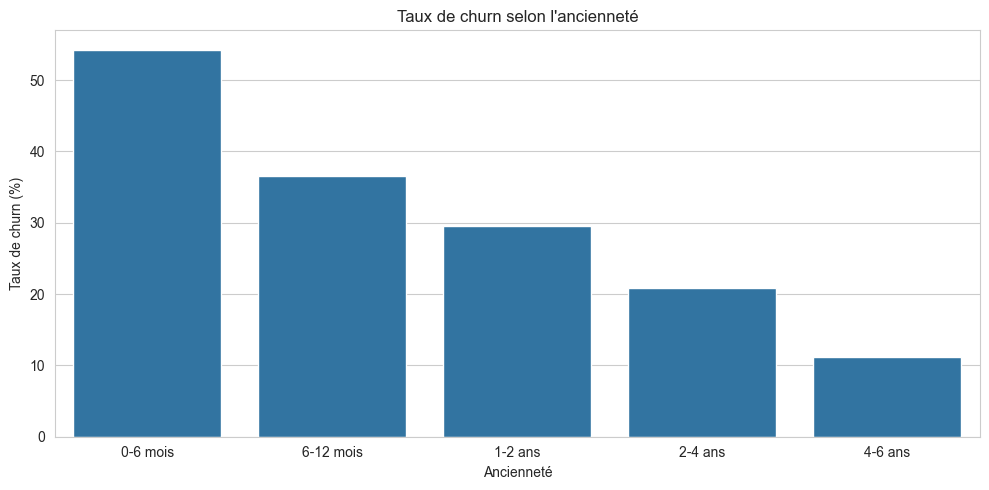

In [87]:
# 1. Churn selon l'ancienneté

plt.figure(figsize=(10, 5))

sns.barplot(
    data=analyse_anciennete.reset_index(),
    x="tenure_group",
    y="taux_churn"
)

plt.title("Taux de churn selon l'ancienneté")
plt.xlabel("Ancienneté")
plt.ylabel("Taux de churn (%)")

plt.tight_layout()
plt.show()

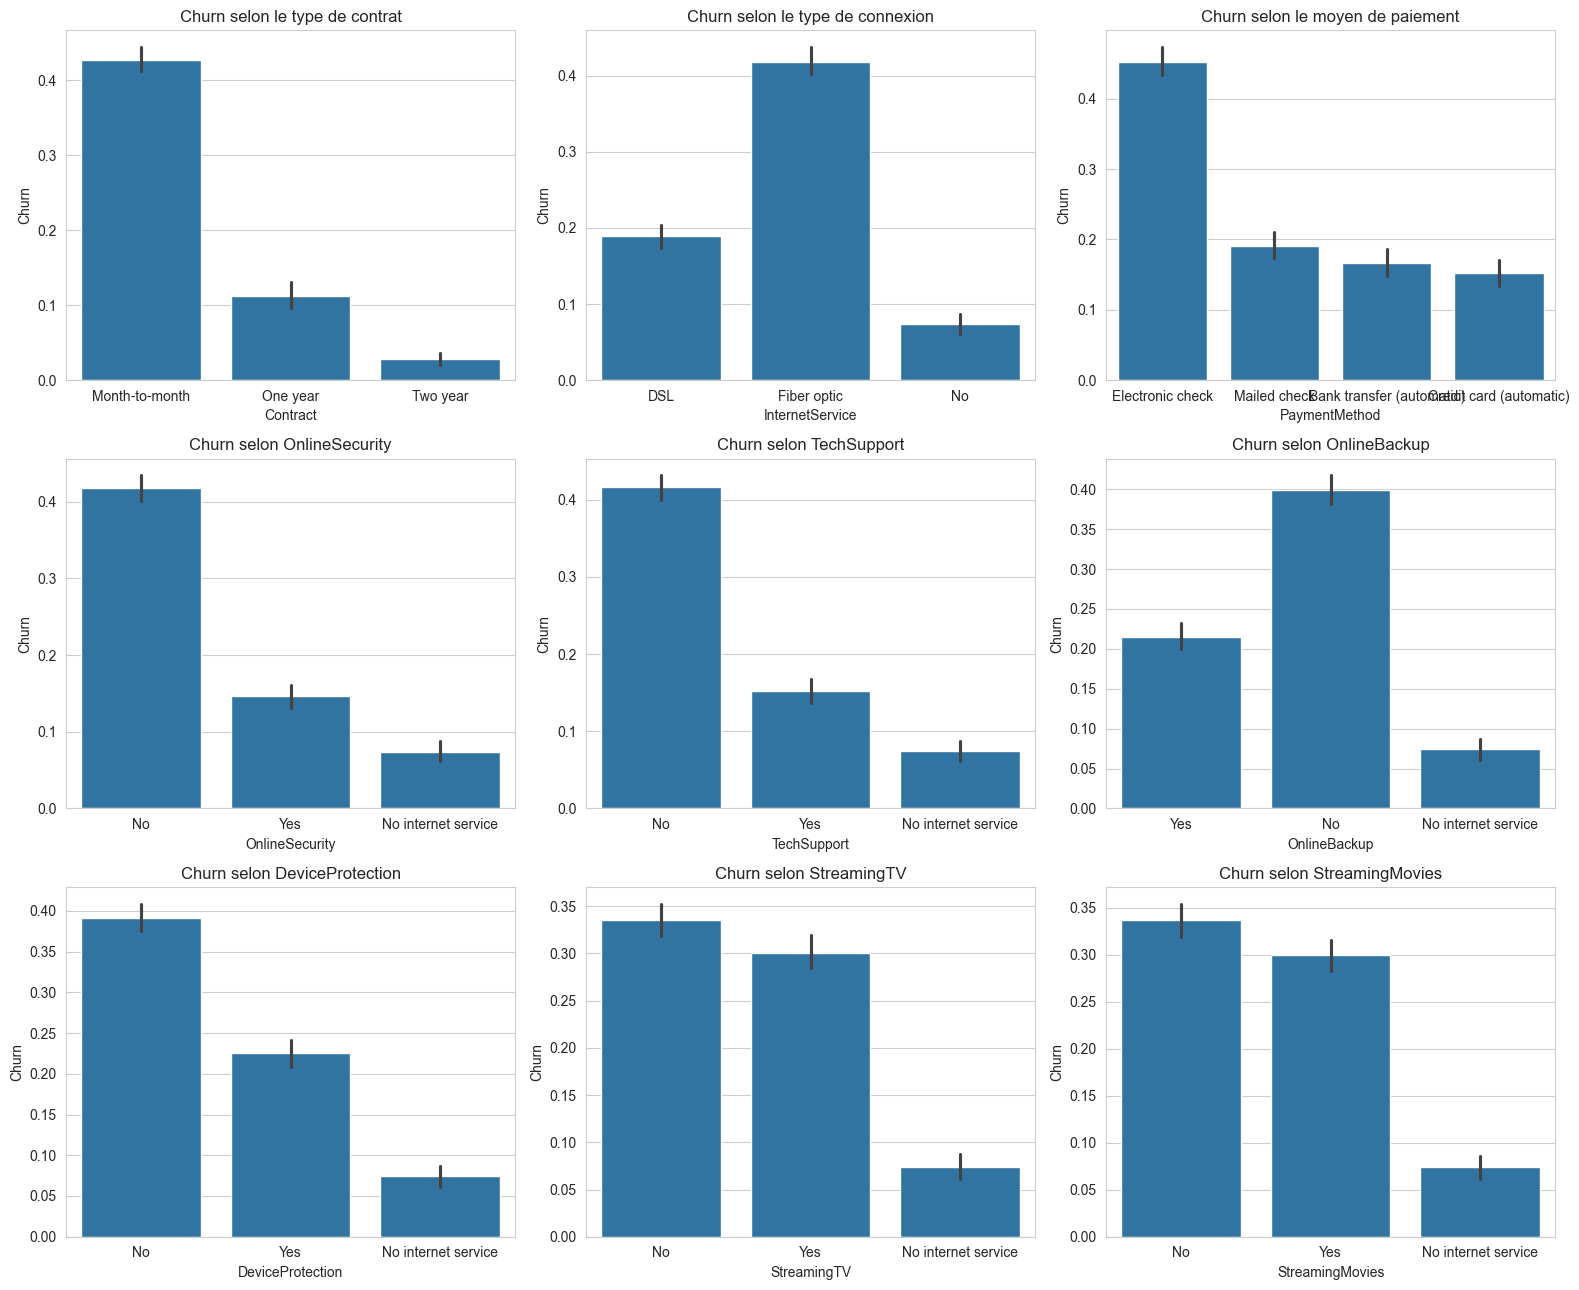

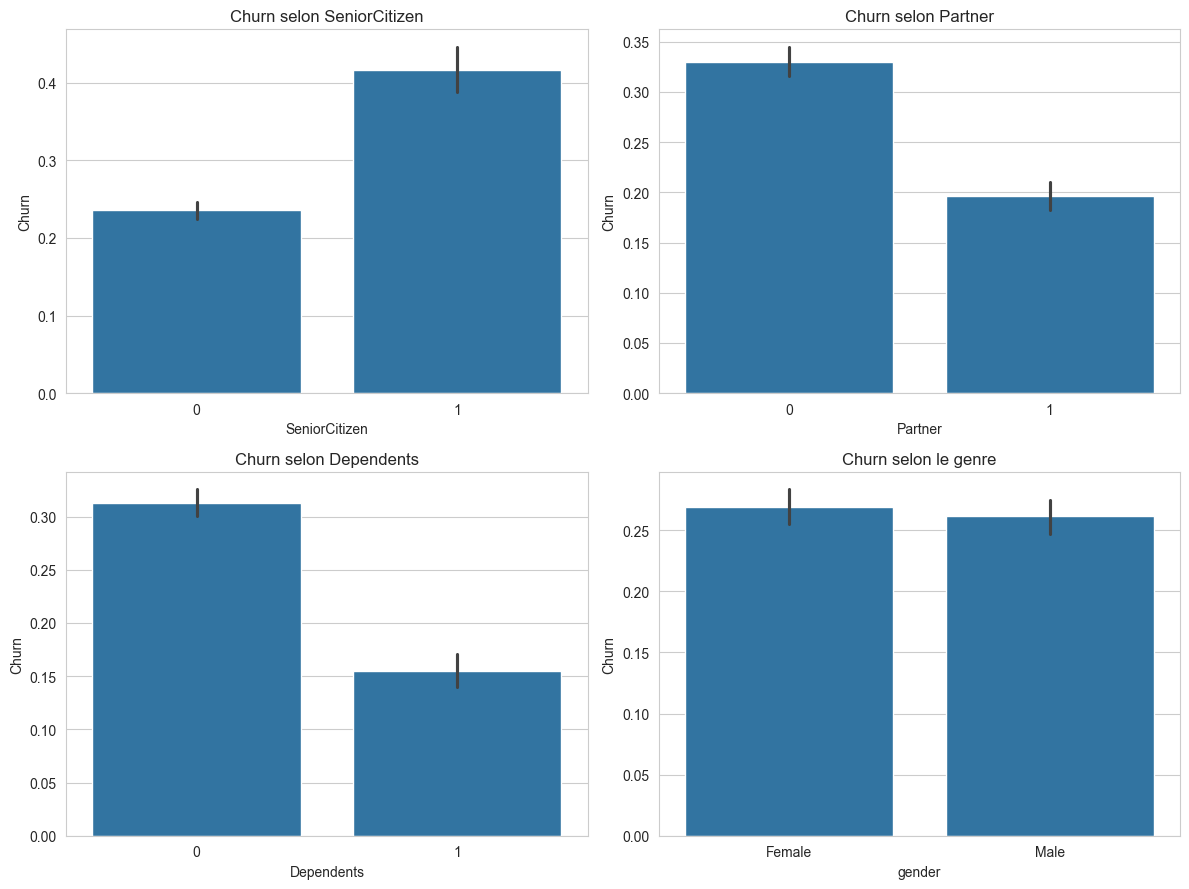

In [88]:
# 2. Variables catégorielles

fig, axes = plt.subplots(3, 3, figsize=(16, 13))

sns.barplot(data=df_clean, x="Contract", y="Churn", ax=axes[0, 0])
axes[0, 0].set_title("Churn selon le type de contrat")

sns.barplot(data=df_clean, x="InternetService", y="Churn", ax=axes[0, 1])
axes[0, 1].set_title("Churn selon le type de connexion")

sns.barplot(data=df_clean, x="PaymentMethod", y="Churn", ax=axes[0, 2])
axes[0, 2].set_title("Churn selon le moyen de paiement")

sns.barplot(data=df_clean, x="OnlineSecurity", y="Churn", ax=axes[1, 0])
axes[1, 0].set_title("Churn selon OnlineSecurity")

sns.barplot(data=df_clean, x="TechSupport", y="Churn", ax=axes[1, 1])
axes[1, 1].set_title("Churn selon TechSupport")

sns.barplot(data=df_clean, x="OnlineBackup", y="Churn", ax=axes[1, 2])
axes[1, 2].set_title("Churn selon OnlineBackup")

sns.barplot(data=df_clean, x="DeviceProtection", y="Churn", ax=axes[2, 0])
axes[2, 0].set_title("Churn selon DeviceProtection")

sns.barplot(data=df_clean, x="StreamingTV", y="Churn", ax=axes[2, 1])
axes[2, 1].set_title("Churn selon StreamingTV")

sns.barplot(data=df_clean, x="StreamingMovies", y="Churn", ax=axes[2, 2])
axes[2, 2].set_title("Churn selon StreamingMovies")

plt.tight_layout()
plt.show()


# Variables démographiques

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

sns.barplot(data=df_clean, x="SeniorCitizen", y="Churn", ax=axes[0, 0])
axes[0, 0].set_title("Churn selon SeniorCitizen")

sns.barplot(data=df_clean, x="Partner", y="Churn", ax=axes[0, 1])
axes[0, 1].set_title("Churn selon Partner")

sns.barplot(data=df_clean, x="Dependents", y="Churn", ax=axes[1, 0])
axes[1, 0].set_title("Churn selon Dependents")

sns.barplot(data=df_clean, x="gender", y="Churn", ax=axes[1, 1])
axes[1, 1].set_title("Churn selon le genre")

plt.tight_layout()
plt.show()

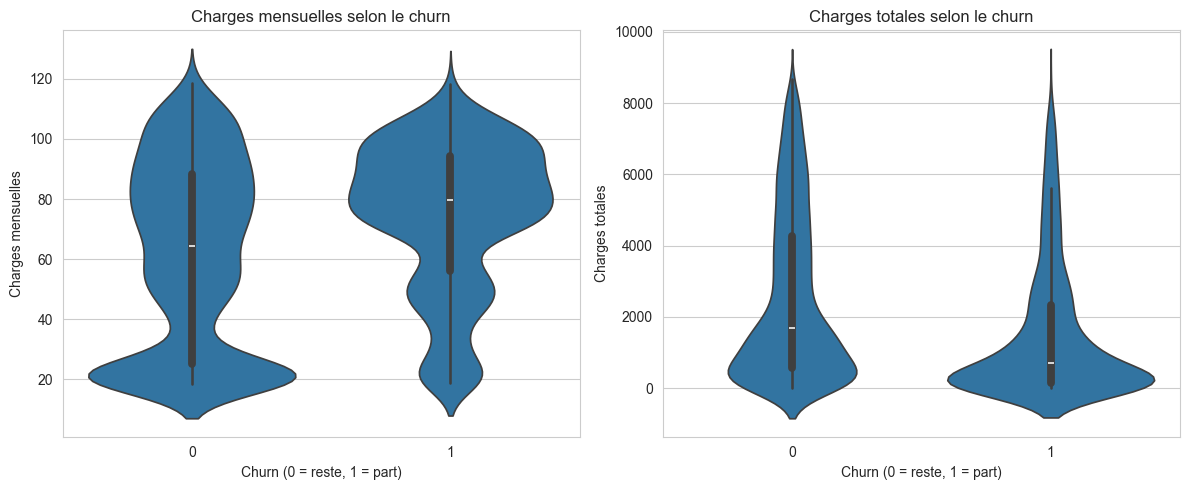

In [89]:
# 3. Variables numériques

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.violinplot(
    data=df_clean,
    x="Churn",
    y="MonthlyCharges",
    ax=axes[0]
)

axes[0].set_title("Charges mensuelles selon le churn")
axes[0].set_xlabel("Churn (0 = reste, 1 = part)")
axes[0].set_ylabel("Charges mensuelles")


sns.violinplot(
    data=df_clean,
    x="Churn",
    y="TotalCharges",
    ax=axes[1]
)

axes[1].set_title("Charges totales selon le churn")
axes[1].set_xlabel("Churn (0 = reste, 1 = part)")
axes[1].set_ylabel("Charges totales")

plt.tight_layout()
plt.show()

**Phase 4 : Feature Engineering**

In [ ]:
# Création de nouvelles variables

df_features = df_clean.copy()

# 1. Variables d'ancienneté
df_features["tenure_years"] = df_features["tenure"] / 12

df_features["is_new_customer"] = (
    df_features["tenure"] <= 6
).astype(int)

df_features["is_young_customer"] = (
    df_features["tenure"] <= 12
).astype(int)


# 2. Segmentation des charges mensuelles
q1 = df_features["MonthlyCharges"].quantile(0.25)
q3 = df_features["MonthlyCharges"].quantile(0.75)

df_features["high_monthly_charges"] = (
    df_features["MonthlyCharges"] > q3
).astype(int)

df_features["low_monthly_charges"] = (
    df_features["MonthlyCharges"] < q1
).astype(int)


# 3. Nombre de services additionnels
services_cols = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df_features["num_services"] = (
    df_features[services_cols] == "Yes"
).sum(axis=1)

df_features["has_multiple_services"] = (
    df_features["num_services"] >= 2
).astype(int)


# 4. Indicateurs de support et sécurité
df_features["has_tech_support"] = (
    df_features["TechSupport"] == "Yes"
).astype(int)

df_features["has_security"] = (
    df_features["OnlineSecurity"] == "Yes"
).astype(int)


# 5. Paiement automatique
automatic_payment = [
    "Bank transfer (automatic)",
    "Credit card (automatic)"
]

df_features["is_automatic_payment"] = (
    df_features["PaymentMethod"].isin(automatic_payment)
).astype(int)


# 6. Contrat long terme
df_features["is_long_contract"] = (
    df_features["Contract"].isin(["One year", "Two year"])
).astype(int)


# 7. Profil à risque
df_features["risky_profile"] = (
    (df_features["is_new_customer"] == 1) &
    (df_features["Contract"] == "Month-to-month")
).astype(int)


# 8. Vérification
new_features = [
    "tenure_years",
    "is_new_customer",
    "is_young_customer",
    "high_monthly_charges",
    "low_monthly_charges",
    "num_services",
    "has_multiple_services",
    "has_tech_support",
    "has_security",
    "is_automatic_payment",
    "is_long_contract",
    "risky_profile"
]

print("Nouvelles variables :")

for feature in new_features:
    print(feature)

print("\nDimensions :", df_features.shape)


# 9. Échantillon
cols_to_show = [
    "customerID",
    "tenure",
    "tenure_years",
    "is_new_customer",
    "Contract",
    "num_services",
    "is_automatic_payment",
    "Churn"
]

print("\nÉchantillon :")
print(df_features[cols_to_show].head(10))

Nouvelles variables :
tenure_years
is_new_customer
is_young_customer
high_monthly_charges
low_monthly_charges
num_services
has_multiple_services
has_tech_support
has_security
is_automatic_payment
is_long_contract
risky_profile

Dimensions : (7043, 34)

Échantillon :
   customerID  tenure  tenure_years  is_new_customer        Contract  \
0  7590-VHVEG       1      0.083333                1  Month-to-month   
1  5575-GNVDE      34      2.833333                0        One year   
2  3668-QPYBK       2      0.166667                1  Month-to-month   
3  7795-CFOCW      45      3.750000                0        One year   
4  9237-HQITU       2      0.166667                1  Month-to-month   
5  9305-CDSKC       8      0.666667                0  Month-to-month   
6  1452-KIOVK      22      1.833333                0  Month-to-month   
7  6713-OKOMC      10      0.833333                0  Month-to-month   
8  7892-POOKP      28      2.333333                0  Month-to-month   
9  6388-TABGU

**Phase 5 : Préparation Machine Learning**

In [100]:
# Importation des librairies pour la préparation des données

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [101]:
# 1. Séparer les variables explicatives et la cible

X = df_features.drop(
    columns=["Churn", "customerID", "tenure_group"]
)

y = df_features["Churn"]

print("Nombre de variables :", X.shape[1])
print("Nombre de clients :", len(y))

print("\nRépartition du churn :")
print("Churn = 0 :", (y == 0).sum())
print("Churn = 1 :", (y == 1).sum())

Nombre de variables : 31
Nombre de clients : 7043

Répartition du churn :
Churn = 0 : 5174
Churn = 1 : 1869


In [102]:
# 2. Séparer les données en train et test

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train :", X_train.shape)
print("Test :", X_test.shape)

print("\nTaux de churn dans train :", y_train.mean())
print("Taux de churn dans test :", y_test.mean())

Train : (5634, 31)
Test : (1409, 31)

Taux de churn dans train : 0.2653532126375577
Taux de churn dans test : 0.2654364797728886


In [103]:
# 3. Identifier les types de variables

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Variables numériques :", len(numeric_features))
print(numeric_features)

print("\nVariables catégorielles :", len(categorical_features))
print(categorical_features)

Variables numériques : 20
['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'tenure_years', 'is_new_customer', 'is_young_customer', 'high_monthly_charges', 'low_monthly_charges', 'num_services', 'has_multiple_services', 'has_tech_support', 'has_security', 'is_automatic_payment', 'is_long_contract', 'risky_profile']

Variables catégorielles : 11
['gender', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']


In [104]:
# 4. Préparer le preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(
            drop="first",
            handle_unknown="ignore",
            sparse_output=False
        ), categorical_features)
    ]
)

print("Preprocessor créé.")

Preprocessor créé.


In [105]:
# 5. Appliquer le preprocessing

X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("X_train :", X_train_processed.shape)
print("X_test :", X_test_processed.shape)

X_train : (5634, 42)
X_test : (1409, 42)


In [106]:
# 6. Récupérer les noms des variables

feature_names_numeric = numeric_features

feature_names_categorical = (
    preprocessor
    .named_transformers_["cat"]
    .get_feature_names_out(categorical_features)
    .tolist()
)

all_feature_names = (
    feature_names_numeric + feature_names_categorical
)

print("Nombre total de variables :", len(all_feature_names))

print("\nPremières variables :")
print(all_feature_names[:10])

Nombre total de variables : 42

Premières variables :
['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'tenure_years', 'is_new_customer']


**Phase 6 : Modèles Machine Learning**

In [107]:
# Import des librairies pour la modélisation

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)


In [113]:
# 1. Entraîner Logistic Regression

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_processed, y_train)


# Prédictions
y_pred_lr = lr_model.predict(X_test_processed)
y_proba_lr = lr_model.predict_proba(X_test_processed)[:, 1]


# Métriques
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_proba_lr)

print("Logistic Regression")
print("Accuracy :", round(accuracy_lr, 4))
print("Precision :", round(precision_lr, 4))
print("Recall :", round(recall_lr, 4))
print("F1-Score :", round(f1_lr, 4))
print("ROC-AUC :", round(roc_auc_lr, 4))

Logistic Regression
Accuracy : 0.8027
Precision : 0.6633
Recall : 0.5214
F1-Score : 0.5838
ROC-AUC : 0.8452


In [111]:
# 2. Random Forest

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train_processed, y_train)

# Prédictions
y_pred_rf = rf_model.predict(X_test_processed)
y_proba_rf = rf_model.predict_proba(X_test_processed)[:, 1]

# Métriques
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_proba_rf)

print("Random Forest")
print("Accuracy :", round(accuracy_rf, 4))
print("Precision :", round(precision_rf, 4))
print("Recall :", round(recall_rf, 4))
print("F1-Score :", round(f1_rf, 4))
print("ROC-AUC :", round(roc_auc_rf, 4))

Random Forest
Accuracy : 0.7651
Precision : 0.5399
Recall : 0.7781
F1-Score : 0.6375
ROC-AUC : 0.8446


In [114]:
# 3. Comparaison des modèles

comparison = pd.DataFrame({
    "Logistic Regression": [
        accuracy_lr,
        precision_lr,
        recall_lr,
        f1_lr,
        roc_auc_lr
    ],
    "Random Forest": [
        accuracy_rf,
        precision_rf,
        recall_rf,
        f1_rf,
        roc_auc_rf
    ]
}, index=[
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
])

print(comparison.round(4))

           Logistic Regression  Random Forest
Accuracy                0.8027         0.7651
Precision               0.6633         0.5399
Recall                  0.5214         0.7781
F1-Score                0.5838         0.6375
ROC-AUC                 0.8452         0.8446


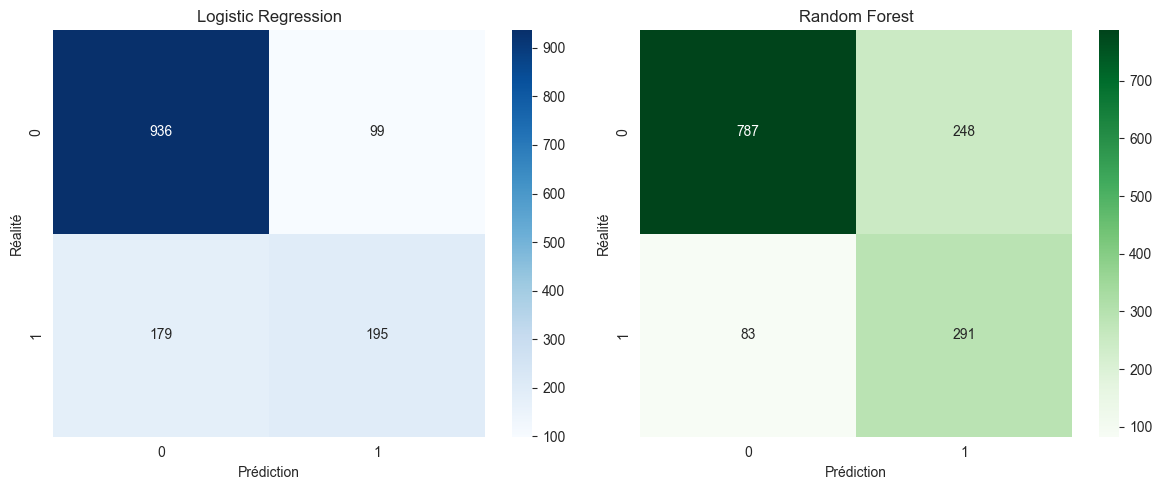

In [115]:
# 4. Matrices de confusion

cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression")
plt.xlabel("Prédiction")
plt.ylabel("Réalité")

plt.subplot(1, 2, 2)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.title("Random Forest")
plt.xlabel("Prédiction")
plt.ylabel("Réalité")

plt.tight_layout()
plt.show()

**Phase 7 : SHAP**

In [120]:
# Importation des librairies pour l'exploration SHAP

import shap

# 1. Créer l'explainer SHAP

explainer = shap.TreeExplainer(rf_model)

print("Explainer SHAP créé.")

# 2. Calculer les valeurs SHAP

shap_values = explainer.shap_values(X_test_processed)

print("Valeurs SHAP calculées.")
print("Type :", type(shap_values))

# 3. Vérifier les dimensions des valeurs SHAP

print("Dimensions SHAP :", shap_values.shape)

# 4. Valeurs SHAP pour la classe Churn = 1

shap_values_churn = shap_values[:, :, 1]

print("Dimensions SHAP Churn :", shap_values_churn.shape)

Explainer SHAP créé.
Valeurs SHAP calculées.
Type : <class 'numpy.ndarray'>
Dimensions SHAP : (1409, 42, 2)
Dimensions SHAP Churn : (1409, 42)


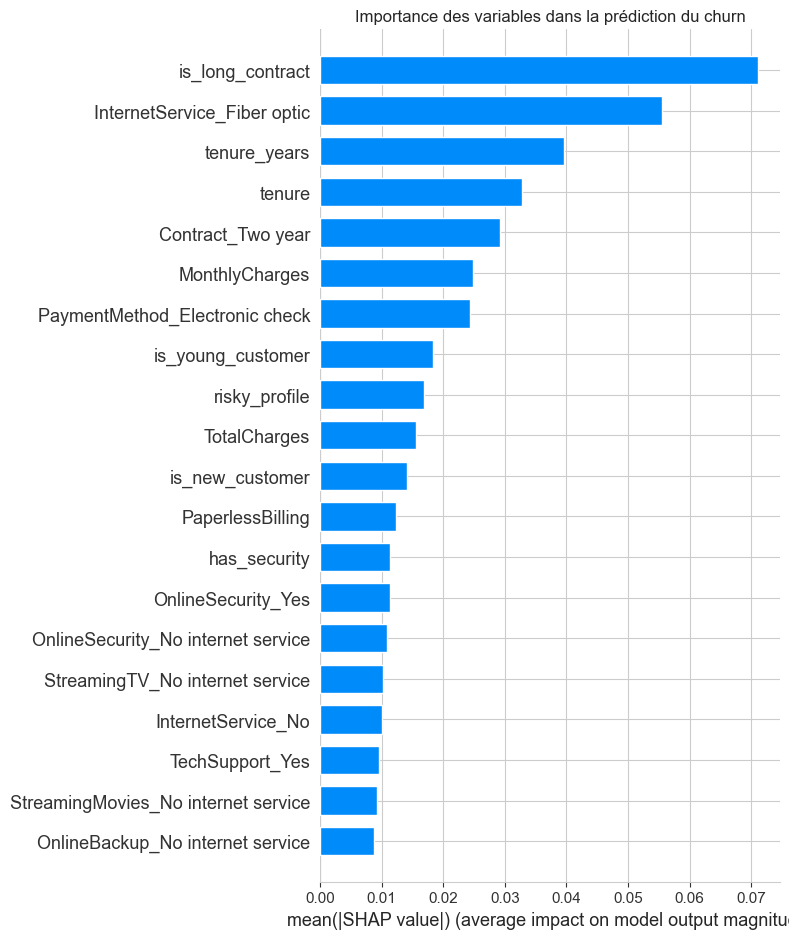

In [121]:
# 5. Importance globale des variables

plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values_churn,
    X_test_processed,
    feature_names=all_feature_names,
    plot_type="bar",
    show=False
)

plt.title("Importance des variables dans la prédiction du churn")
plt.tight_layout()
plt.show()

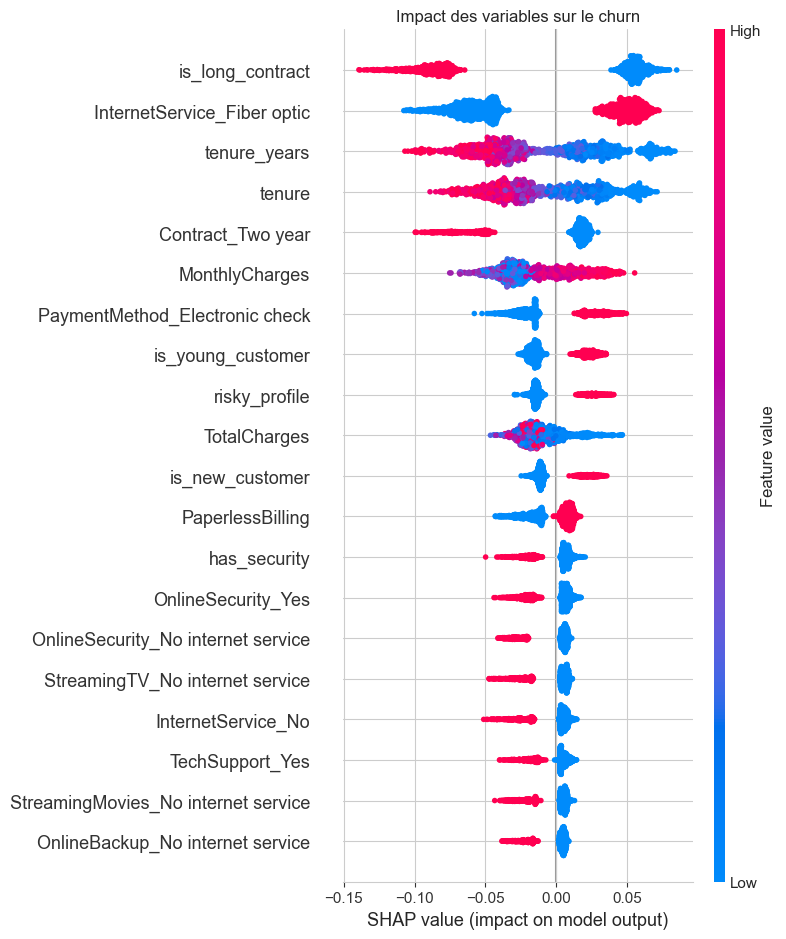

In [122]:
# 6. Impact des variables sur le churn

plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values_churn,
    X_test_processed,
    feature_names=all_feature_names,
    show=False
)

plt.title("Impact des variables sur le churn")
plt.tight_layout()
plt.show()

In [123]:
# 7. Classement des variables par importance SHAP

feature_importance = pd.DataFrame({
    "feature": all_feature_names,
    "importance": np.abs(shap_values_churn).mean(axis=0)
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

print(feature_importance.head(15))

                               feature  importance
18                    is_long_contract    0.071123
23         InternetService_Fiber optic    0.055549
8                         tenure_years    0.039641
3                               tenure    0.032792
38                   Contract_Two year    0.029146
6                       MonthlyCharges    0.024893
40      PaymentMethod_Electronic check    0.024286
10                   is_young_customer    0.018303
19                       risky_profile    0.016792
7                         TotalCharges    0.015552
9                      is_new_customer    0.014119
5                     PaperlessBilling    0.012370
16                        has_security    0.011410
26                  OnlineSecurity_Yes    0.011359
25  OnlineSecurity_No internet service    0.010816


In [124]:
# 8. Top 5 des facteurs de churn

top_5 = feature_importance.head(5)

print("Top 5 des variables les plus importantes :")
print(top_5.to_string(index=False))

Top 5 des variables les plus importantes :
                    feature  importance
           is_long_contract    0.071123
InternetService_Fiber optic    0.055549
               tenure_years    0.039641
                     tenure    0.032792
          Contract_Two year    0.029146


In [126]:
# 9. Analyse des clients à risque

risk_scores = y_proba_rf

test_results = pd.DataFrame({
    "risk_score": risk_scores,
    "predicted_churn": y_pred_rf,
    "actual_churn": y_test.values
})

test_results = test_results.sort_values(
    "risk_score",
    ascending=False
).reset_index(drop=True)

print("Clients avec risque de churn > 70% :",
      (test_results["risk_score"] > 0.70).sum())

print("Clients avec risque de churn > 50% :",
      (test_results["risk_score"] > 0.50).sum())

print("Clients avec risque de churn > 30% :",
      (test_results["risk_score"] > 0.30).sum())

Clients avec risque de churn > 70% : 295
Clients avec risque de churn > 50% : 539
Clients avec risque de churn > 30% : 753


In [127]:
# 10. Waterfall Plot pour 3 clients représentatifs

idx_high_risk = test_results[test_results["risk_score"] > 0.90].index[0]

idx_medium_risk = test_results[
    (test_results["risk_score"] > 0.50) &
    (test_results["risk_score"] <= 0.70)
].index[0]

idx_low_risk = test_results[
    test_results["risk_score"] < 0.30
].index[-1]

print("Profils sélectionnés :")
print("Risque élevé :", test_results.loc[idx_high_risk, "risk_score"])
print("Risque moyen :", test_results.loc[idx_medium_risk, "risk_score"])
print("Risque faible :", test_results.loc[idx_low_risk, "risk_score"])

Profils sélectionnés :
Risque élevé : 0.9576485785206046
Risque moyen : 0.6990501309304274
Risque faible : 0.0027036796705094943


C:\Users\PC\AppData\Local\Temp\ipykernel_8676\1613497659.py:29: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


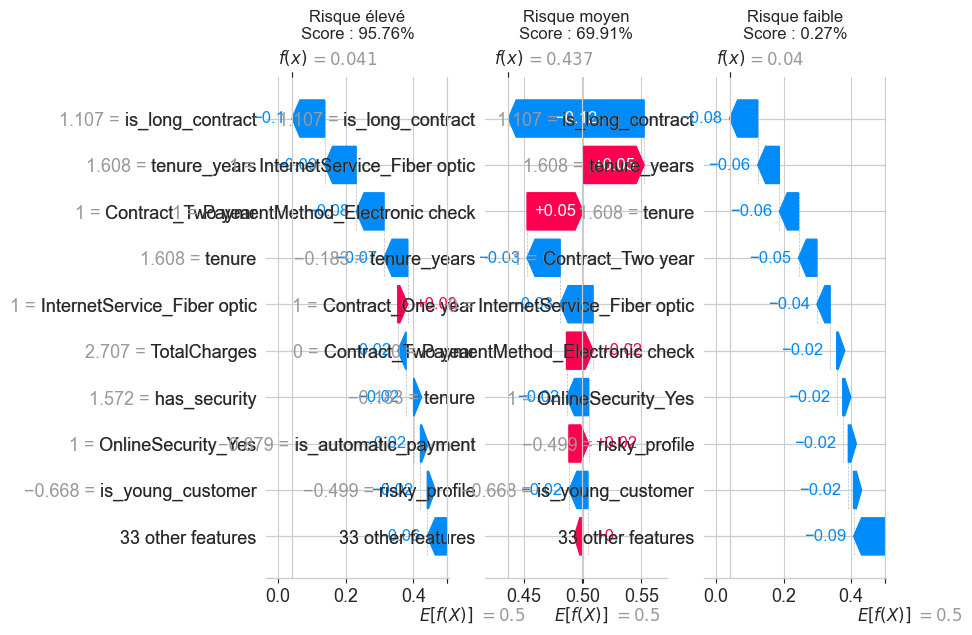

In [131]:
# 11. Waterfall Plot des 3 profils

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

profils = [
    (idx_high_risk, "Risque élevé"),
    (idx_medium_risk, "Risque moyen"),
    (idx_low_risk, "Risque faible")
]

for i, (idx, niveau) in enumerate(profils):

    plt.sca(axes[i])

    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values_churn[idx],
            base_values=explainer.expected_value[1],
            data=X_test_processed[idx],
            feature_names=all_feature_names
        ),
        show=False
    )

    axes[i].set_title(
        f"{niveau}\nScore : {test_results.loc[idx, 'risk_score']:.2%}"
    )

plt.tight_layout()
plt.show()

In [132]:
# 12. Synthèse des insights SHAP

print("="*80)
print("INSIGHTS CLÉS DE SHAP")
print("="*80)

top_features = feature_importance.head(5)["feature"].tolist()

print("\nTop 5 des facteurs de prédiction du churn :")

for i, feature in enumerate(top_features, 1):
    importance = feature_importance[
        feature_importance["feature"] == feature
    ]["importance"].values[0]

    print(f"{i}. {feature} : {importance:.4f}")

print("\nInterprétation métier :")
print("• Les contrats et l'ancienneté sont parmi les facteurs les plus importants.")
print("• Le type de service Internet influence fortement le risque de churn.")
print("• Les charges mensuelles et le mode de paiement jouent également un rôle.")
print("• Les variables de risque combiné permettent d'identifier les profils à surveiller.")

INSIGHTS CLÉS DE SHAP

Top 5 des facteurs de prédiction du churn :
1. is_long_contract : 0.0711
2. InternetService_Fiber optic : 0.0555
3. tenure_years : 0.0396
4. tenure : 0.0328
5. Contract_Two year : 0.0291

Interprétation métier :
• Les contrats et l'ancienneté sont parmi les facteurs les plus importants.
• Le type de service Internet influence fortement le risque de churn.
• Les charges mensuelles et le mode de paiement jouent également un rôle.
• Les variables de risque combiné permettent d'identifier les profils à surveiller.


**Phase 8 : Segmentation des clients à risque**

In [133]:
print("Phase 8 : Segmentation des clients à risque")
print("="*80)

# 1. Création de la table de segmentation

segmentation = X_test.copy()

segmentation["risk_score"] = y_proba_rf
segmentation["predicted_churn"] = y_pred_rf
segmentation["actual_churn"] = y_test.values

def assign_risk_category(score):
    if score >= 0.70:
        return "ÉLEVÉ"
    elif score >= 0.40:
        return "MOYEN"
    else:
        return "FAIBLE"

segmentation["risk_category"] = segmentation["risk_score"].apply(
    assign_risk_category
)

print(f"Table de segmentation créée : {segmentation.shape}")

Phase 8 : Segmentation des clients à risque
Table de segmentation créée : (1409, 35)


In [134]:
# 2. Distribution des clients par risque

risk_dist = segmentation["risk_category"].value_counts()

print("\nDistribution des clients par risque :")
print(risk_dist)

for category in ["ÉLEVÉ", "MOYEN", "FAIBLE"]:
    count = len(segmentation[segmentation["risk_category"] == category])
    pct = count / len(segmentation) * 100

    print(f"\n{category} : {count:,} clients ({pct:.1f}%)")


Distribution des clients par risque :
risk_category
FAIBLE    782
MOYEN     332
ÉLEVÉ     295
Name: count, dtype: int64

ÉLEVÉ : 295 clients (20.9%)

MOYEN : 332 clients (23.6%)

FAIBLE : 782 clients (55.5%)


In [135]:
# 3. Profil des clients à risque ÉLEVÉ

print("="*80)
print("PROFIL DES CLIENTS À RISQUE ÉLEVÉ (score >= 70%)")
print("="*80)

high_risk = segmentation[
    segmentation["risk_category"] == "ÉLEVÉ"
]

print(f"\nNombre de clients : {len(high_risk):,}")

print(
    f"Churn réel dans ce groupe : "
    f"{high_risk['actual_churn'].sum()} / {len(high_risk)} "
    f"({high_risk['actual_churn'].mean()*100:.1f}%)"
)

print("\nCaractéristiques principales :")

print("\nAncienneté :")
print(
    f"  Moyenne : {high_risk['tenure'].mean():.1f} mois "
    f"({high_risk['tenure_years'].mean():.2f} ans)"
)
print(f"  Médiane : {high_risk['tenure'].median():.0f} mois")
print(
    f"  % clients <= 6 mois : "
    f"{(high_risk['tenure'] <= 6).mean()*100:.1f}%"
)

print("\nType de contrat :")
print(high_risk["Contract"].value_counts())

print("\nService Internet :")
print(high_risk["InternetService"].value_counts())

print("\nMéthode de paiement :")
print(high_risk["PaymentMethod"].value_counts())

print("\nCharges mensuelles :")
print(f"  Moyenne : ${high_risk['MonthlyCharges'].mean():.2f}")
print(f"  Médiane : ${high_risk['MonthlyCharges'].median():.2f}")
print(
    f"  % > $80/mois : "
    f"{(high_risk['MonthlyCharges'] > 80).mean()*100:.1f}%"
)

print("\nServices additionnels :")
print(f"  Nombre moyen : {high_risk['num_services'].mean():.2f}")
print(
    f"  % sans services : "
    f"{(high_risk['num_services'] == 0).mean()*100:.1f}%"
)

PROFIL DES CLIENTS À RISQUE ÉLEVÉ (score >= 70%)

Nombre de clients : 295
Churn réel dans ce groupe : 196 / 295 (66.4%)

Caractéristiques principales :

Ancienneté :
  Moyenne : 8.1 mois (0.67 ans)
  Médiane : 4 mois
  % clients <= 6 mois : 63.4%

Type de contrat :
Contract
Month-to-month    295
Name: count, dtype: int64

Service Internet :
InternetService
Fiber optic    241
DSL             54
Name: count, dtype: int64

Méthode de paiement :
PaymentMethod
Electronic check             205
Mailed check                  46
Bank transfer (automatic)     23
Credit card (automatic)       21
Name: count, dtype: int64

Charges mensuelles :
  Moyenne : $76.85
  Médiane : $78.80
  % > $80/mois : 45.1%

Services additionnels :
  Nombre moyen : 1.32
  % sans services : 32.9%


In [136]:
# 4. Profil des clients à risque MOYEN

print("="*80)
print("PROFIL DES CLIENTS À RISQUE MOYEN (40% <= score < 70%)")
print("="*80)

medium_risk = segmentation[
    segmentation["risk_category"] == "MOYEN"
]

print(f"\nNombre de clients : {len(medium_risk):,}")

print(
    f"Churn réel dans ce groupe : "
    f"{medium_risk['actual_churn'].sum()} / {len(medium_risk)} "
    f"({medium_risk['actual_churn'].mean()*100:.1f}%)"
)

print("\nCaractéristiques principales :")

print("\nAncienneté :")
print(
    f"  Moyenne : {medium_risk['tenure'].mean():.1f} mois "
    f"({medium_risk['tenure_years'].mean():.2f} ans)"
)

print("\nType de contrat :")
contract_dist = medium_risk["Contract"].value_counts().head(3)

for contract, count in contract_dist.items():
    pct = count / len(medium_risk) * 100
    print(f"  {contract} : {count:,} ({pct:.1f}%)")

print("\nService Internet :")
internet_dist = medium_risk["InternetService"].value_counts()

for service, count in internet_dist.items():
    pct = count / len(medium_risk) * 100
    print(f"  {service} : {count:,} ({pct:.1f}%)")

print("\nCharges mensuelles :")
print(f"  Moyenne : ${medium_risk['MonthlyCharges'].mean():.2f}")
print(f"  Médiane : ${medium_risk['MonthlyCharges'].median():.2f}")

print("\nServices additionnels :")
print(f"  Nombre moyen : {medium_risk['num_services'].mean():.2f}")

PROFIL DES CLIENTS À RISQUE MOYEN (40% <= score < 70%)

Nombre de clients : 332
Churn réel dans ce groupe : 119 / 332 (35.8%)

Caractéristiques principales :

Ancienneté :
  Moyenne : 23.6 mois (1.96 ans)

Type de contrat :
  Month-to-month : 296 (89.2%)
  One year : 36 (10.8%)

Service Internet :
  Fiber optic : 195 (58.7%)
  DSL : 104 (31.3%)
  No : 33 (9.9%)

Charges mensuelles :
  Moyenne : $70.85
  Médiane : $77.35

Services additionnels :
  Nombre moyen : 1.91


In [137]:
# 5. Profil des clients à risque FAIBLE

print("="*80)
print("PROFIL DES CLIENTS À RISQUE FAIBLE (score < 40%)")
print("="*80)

low_risk = segmentation[
    segmentation["risk_category"] == "FAIBLE"
]

print(f"\nNombre de clients : {len(low_risk):,}")

print(
    f"Churn réel dans ce groupe : "
    f"{low_risk['actual_churn'].sum()} / {len(low_risk)} "
    f"({low_risk['actual_churn'].mean()*100:.1f}%)"
)

print("\nCaractéristiques principales :")

print("\nAncienneté :")
print(
    f"  Moyenne : {low_risk['tenure'].mean():.1f} mois "
    f"({low_risk['tenure_years'].mean():.2f} ans)"
)

print("\nType de contrat :")
contract_dist = low_risk["Contract"].value_counts().head(3)

for contract, count in contract_dist.items():
    pct = count / len(low_risk) * 100
    print(f"  {contract} : {count:,} ({pct:.1f}%)")

print("\nService Internet :")
internet_dist = low_risk["InternetService"].value_counts()

for service, count in internet_dist.items():
    pct = count / len(low_risk) * 100
    print(f"  {service} : {count:,} ({pct:.1f}%)")

print("\nServices additionnels :")
print(f"  Nombre moyen : {low_risk['num_services'].mean():.2f}")

print(
    f"  % avec OnlineSecurity : "
    f"{(low_risk['OnlineSecurity'] == 'Yes').mean()*100:.1f}%"
)

print(
    f"  % avec TechSupport : "
    f"{(low_risk['TechSupport'] == 'Yes').mean()*100:.1f}%"
)

PROFIL DES CLIENTS À RISQUE FAIBLE (score < 40%)

Nombre de clients : 782
Churn réel dans ce groupe : 59 / 782 (7.5%)

Caractéristiques principales :

Ancienneté :
  Moyenne : 44.5 mois (3.70 ans)

Type de contrat :
  Two year : 336 (43.0%)
  One year : 264 (33.8%)
  Month-to-month : 182 (23.3%)

Service Internet :
  DSL : 326 (41.7%)
  No : 279 (35.7%)
  Fiber optic : 177 (22.6%)

Services additionnels :
  Nombre moyen : 2.22
  % avec OnlineSecurity : 38.6%
  % avec TechSupport : 37.2%


CRÉATION DES VISUALISATIONS DE SEGMENTATION


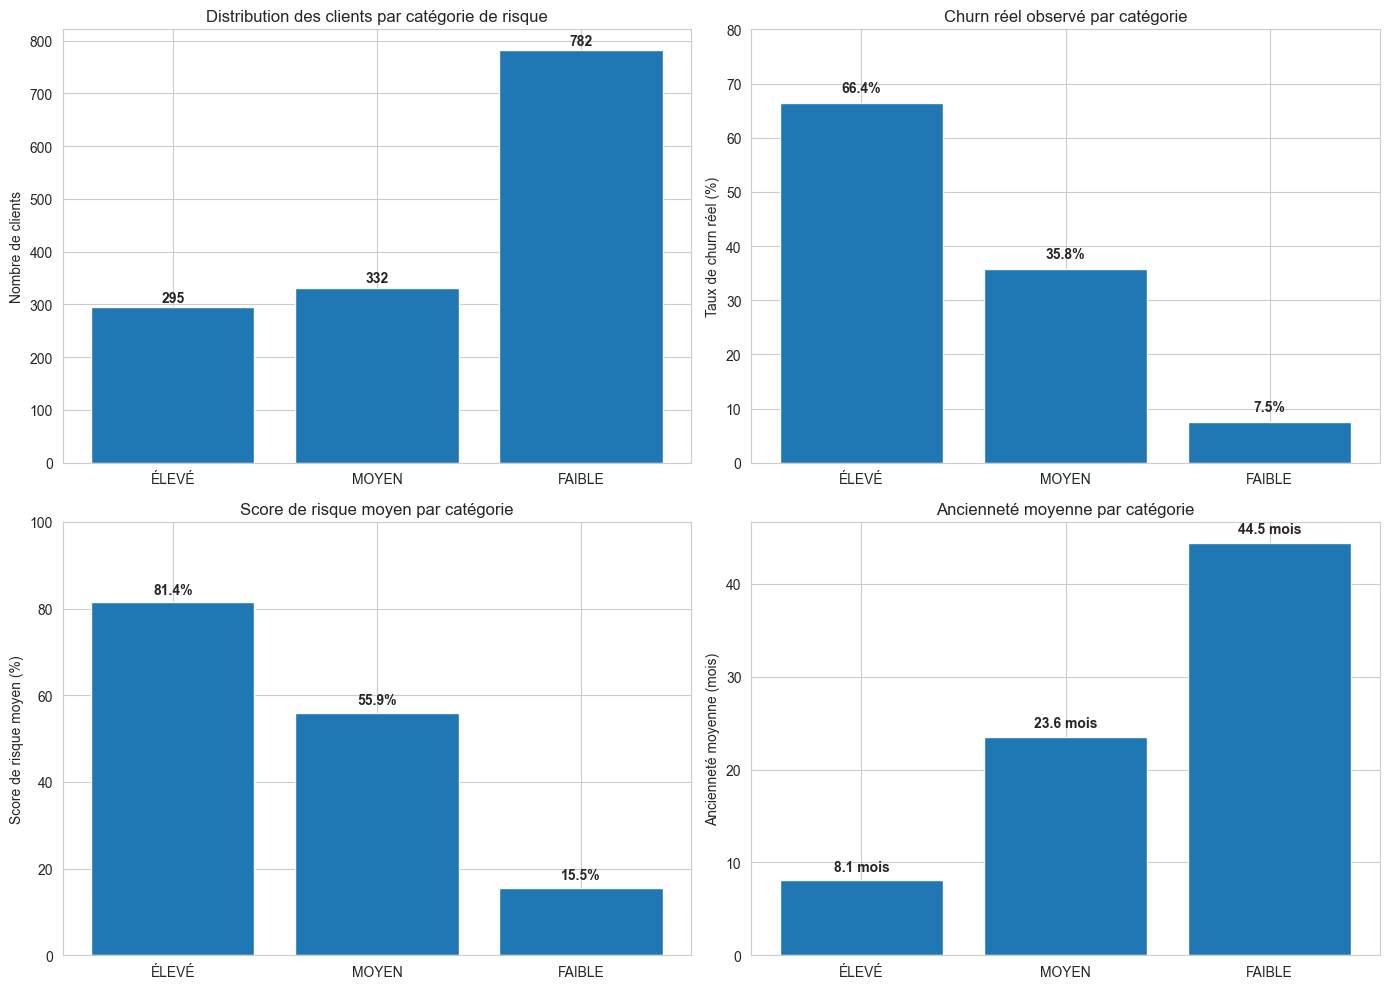

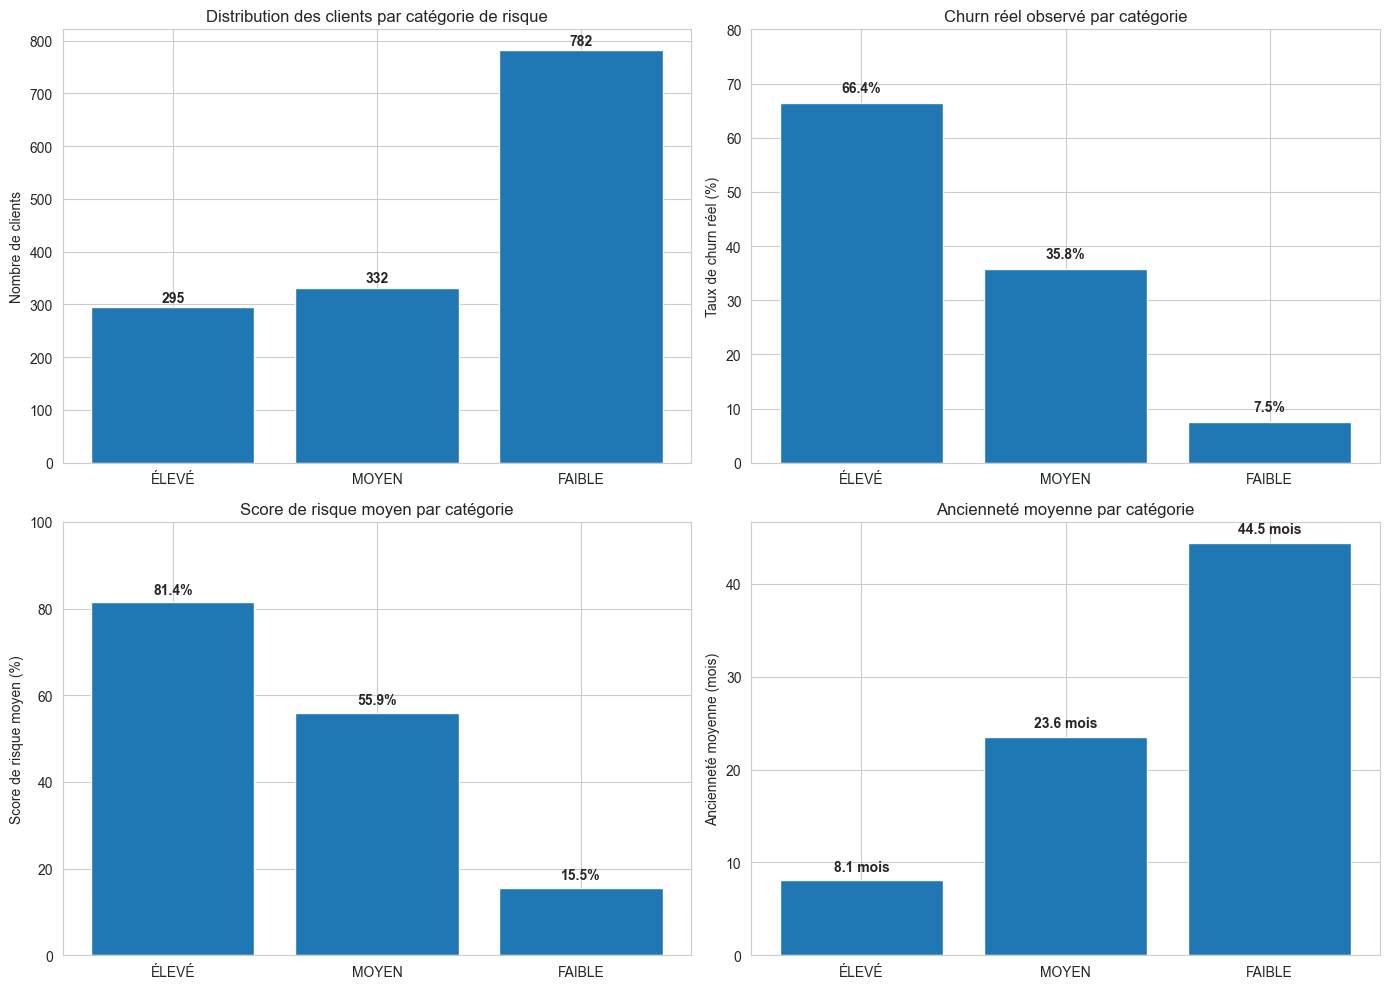

In [139]:
# 6. Visualisations de la segmentation

print("="*80)
print("CRÉATION DES VISUALISATIONS DE SEGMENTATION")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

risk_order = ["ÉLEVÉ", "MOYEN", "FAIBLE"]

# 1. Distribution des clients par catégorie
ax1 = axes[0, 0]

risk_counts = (
    segmentation["risk_category"]
    .value_counts()
    .reindex(risk_order)
)

ax1.bar(risk_order, risk_counts.values)

ax1.set_ylabel("Nombre de clients")
ax1.set_title("Distribution des clients par catégorie de risque")

for i, v in enumerate(risk_counts.values):
    ax1.text(
        i, v + 10,
        str(v),
        ha="center",
        fontweight="bold"
    )

# 2. Churn réel par catégorie
ax2 = axes[0, 1]

churn_by_risk = (
    segmentation
    .groupby("risk_category")["actual_churn"]
    .mean()
    .reindex(risk_order) * 100
)

ax2.bar(risk_order, churn_by_risk.values)

ax2.set_ylabel("Taux de churn réel (%)")
ax2.set_title("Churn réel observé par catégorie")
ax2.set_ylim(0, 80)

for i, v in enumerate(churn_by_risk.values):
    ax2.text(
        i, v + 2,
        f"{v:.1f}%",
        ha="center",
        fontweight="bold"
    )

# 3. Score de risque moyen
ax3 = axes[1, 0]

avg_score_by_risk = (
    segmentation
    .groupby("risk_category")["risk_score"]
    .mean()
    .reindex(risk_order) * 100
)

ax3.bar(risk_order, avg_score_by_risk.values)

ax3.set_ylabel("Score de risque moyen (%)")
ax3.set_title("Score de risque moyen par catégorie")
ax3.set_ylim(0, 100)

for i, v in enumerate(avg_score_by_risk.values):
    ax3.text(
        i, v + 2,
        f"{v:.1f}%",
        ha="center",
        fontweight="bold"
    )

# 4. Ancienneté moyenne
ax4 = axes[1, 1]

avg_tenure_by_risk = (
    segmentation
    .groupby("risk_category")["tenure"]
    .mean()
    .reindex(risk_order)
)

ax4.bar(risk_order, avg_tenure_by_risk.values)

ax4.set_ylabel("Ancienneté moyenne (mois)")
ax4.set_title("Ancienneté moyenne par catégorie")

for i, v in enumerate(avg_tenure_by_risk.values):
    ax4.text(
        i, v + 1,
        f"{v:.1f} mois",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

**Phase 9 : Recommandations métier**

L'analyse de segmentation permet de transformer les résultats du modèle en priorités d'action pour la rétention des clients. Les recommandations ci-dessous sont directement basées sur les profils observés dans les données et sur les niveaux de risque identifiés.

**🔴 1. Segment à risque élevé — Action urgente**

Le segment élevé regroupe **295 clients**, dont **66,4 % ont effectivement churné**. Il constitue donc la priorité principale pour les actions de rétention.

Les profils observés sont notamment caractérisés par :
- une **faible ancienneté**, avec une forte présence de clients récents ;
- une forte concentration de contrats **Month-to-month** ;
- une présence importante de clients utilisant la **Fiber optic** ;
- une proportion notable de clients utilisant **Electronic check** ;
- certains clients disposant de peu ou pas de services additionnels.

**Recommandations**
- Mettre en place un **suivi proactif des clients à risque élevé**.
- Accorder une attention particulière aux **nouveaux clients**.
- Identifier les causes d'insatisfaction avant de proposer une offre commerciale.
- Étudier la possibilité de proposer un **contrat de plus longue durée** lorsque cela est pertinent.
- Investiguer les problèmes éventuels liés aux clients **Fiber optic**.
- Proposer des services additionnels lorsque leur absence est associée à un profil de risque élevé.
- Encourager le passage au **paiement automatique** lorsque cela est pertinent.

---

**🟠 2. Segment à risque moyen — Action prioritaire**

Le segment moyen comprend **332 clients**, avec un **taux de churn réel de 35,8 %**. Ce groupe représente une population intermédiaire qui doit faire l'objet d'une surveillance régulière afin d'éviter une évolution vers le segment à risque élevé.

Les caractéristiques observées montrent notamment une forte présence de clients :
- en contrat **Month-to-month** ;
- avec une ancienneté intermédiaire ;
- utilisant différents services Internet et niveaux de services additionnels.

**Recommandations**
- Mettre en place un **suivi régulier du score de risque**.
- Identifier les clients dont le score se rapproche du seuil de risque élevé.
- Proposer des services additionnels lorsque cela correspond aux besoins du client.
- Encourager progressivement les contrats de plus longue durée.
- Surveiller l'évolution de l'ancienneté, du contrat et des services utilisés.

---

**🟢 3. Segment à faible risque — Maintenance**

Le segment faible représente **782 clients**, avec seulement **7,5 % de churn réel**. Ces clients présentent globalement une ancienneté plus importante et davantage de contrats de longue durée.

**Recommandations**
- Maintenir une **bonne qualité de service**.
- Préserver la satisfaction et la fidélité des clients.
- Surveiller les changements de comportement pouvant entraîner une augmentation du risque.
- Éviter de concentrer des actions commerciales agressives sur cette population.
- Utiliser ce segment comme **population de référence** pour suivre l'évolution des comportements des clients à risque.

---

**🎯 4. Priorisation globale**

| Segment | Clients | Churn réel | Priorité | Orientation |
|---|---:|---:|---|---|
| 🔴 ÉLEVÉ | 295 | **66,4 %** | **Urgente** | Rétention proactive |
| 🟠 MOYEN | 332 | **35,8 %** | **Prioritaire** | Prévention et suivi |
| 🟢 FAIBLE | 782 | **7,5 %** | **Maintenance** | Fidélisation |

**⚠️ Point de vigilance**

Les caractéristiques identifiées dans cette analyse représentent des **associations statistiques** observées dans les données. Elles ne permettent pas, à elles seules, de démontrer qu'une action commerciale donnée entraînera une diminution du churn.

Les recommandations constituent donc des **pistes opérationnelles à tester et à valider** par des expérimentations métier, avant tout déploiement à grande échelle.

**Phase 10 : Application Streamlit**

In [ ]:
%whos

Variable                    Type                      Data/Info
---------------------------------------------------------------
ColumnTransformer           ABCMeta                   <class 'sklearn.compose._<...>ormer.ColumnTransformer'>
LogisticRegression          type                      <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
OneHotEncoder               type                      <class 'sklearn.preproces<...>_encoders.OneHotEncoder'>
Path                        type                      <class 'pathlib._local.Path'>
RandomForestClassifier      ABCMeta                   <class 'sklearn.ensemble.<...>.RandomForestClassifier'>
StandardScaler              type                      <class 'sklearn.preproces<...>ng._data.StandardScaler'>
X                           DataFrame                 Shape: (7043, 31)
X_test                      DataFrame                 Shape: (1409, 31)
X_test_processed            ndarray                   1409x42: 59178 elems, type `float64`, 47

In [143]:
print("=== OBJETS RANDOM FOREST ===")

for name, obj in list(globals().items()):
    if "RandomForestClassifier" in str(type(obj)):
        print(f"{name} → {type(obj)}")

print("\n=== OBJETS PREPROCESSOR ===")

for name, obj in list(globals().items()):
    if "ColumnTransformer" in str(type(obj)):
        print(f"{name} → {type(obj)}")

=== OBJETS RANDOM FOREST ===
rf_model → <class 'sklearn.ensemble._forest.RandomForestClassifier'>

=== OBJETS PREPROCESSOR ===
preprocessor → <class 'sklearn.compose._column_transformer.ColumnTransformer'>


In [144]:
import joblib
from pathlib import Path

# ============================================================
# PHASE 10.1 — SAUVEGARDE DES ARTEFACTS
# ============================================================

# Dossier de sauvegarde
models_dir = Path("models")
models_dir.mkdir(parents=True, exist_ok=True)

# 1. Sauvegarder le Random Forest entraîné
joblib.dump(
    rf_model,
    models_dir / "churn_model.pkl"
)

# 2. Sauvegarder le preprocessor utilisé pendant l'entraînement
joblib.dump(
    preprocessor,
    models_dir / "preprocessor.pkl"
)

# 3. Sauvegarder les noms des features après preprocessing
joblib.dump(
    all_feature_names,
    models_dir / "feature_names.pkl"
)

# 4. Sauvegarder les seuils de segmentation
thresholds = {
    "risk_high": 0.70,
    "risk_medium": 0.40
}

joblib.dump(
    thresholds,
    models_dir / "thresholds.pkl"
)

print("=" * 70)
print("PHASE 10.1 : ARTEFACTS SAUVEGARDÉS")
print("=" * 70)

print(f"\n✓ Modèle       : {models_dir / 'churn_model.pkl'}")
print(f"✓ Preprocessor : {models_dir / 'preprocessor.pkl'}")
print(f"✓ Features     : {models_dir / 'feature_names.pkl'}")
print(f"✓ Seuils       : {models_dir / 'thresholds.pkl'}")

print("\n✓ Sauvegarde terminée avec succès.")

PHASE 10.1 : ARTEFACTS SAUVEGARDÉS

✓ Modèle       : models\churn_model.pkl
✓ Preprocessor : models\preprocessor.pkl
✓ Features     : models\feature_names.pkl
✓ Seuils       : models\thresholds.pkl

✓ Sauvegarde terminée avec succès.


In [146]:
# ============================================================
# PHASE 10.2 : Développement de l’application Streamlit
# ============================================================

print("=== COLONNES UTILISÉES PAR LE PREPROCESSOR ===")

for name, transformer, columns in preprocessor.transformers_:
    print(f"\n{name}")
    print(columns)

print("\n=== FEATURES FINALES ===")
print(len(all_feature_names))
print(all_feature_names)

=== COLONNES UTILISÉES PAR LE PREPROCESSOR ===

num
['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'tenure_years', 'is_new_customer', 'is_young_customer', 'high_monthly_charges', 'low_monthly_charges', 'num_services', 'has_multiple_services', 'has_tech_support', 'has_security', 'is_automatic_payment', 'is_long_contract', 'risky_profile']

cat
['gender', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

=== FEATURES FINALES ===
42
['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'tenure_years', 'is_new_customer', 'is_young_customer', 'high_monthly_charges', 'low_monthly_charges', 'num_services', 'has_multiple_services', 'has_tech_support', 'has_security', 'is_automatic_payment', 'is_long_contract', 'risky_profile', 'gender

**Phase 10.2.1 : Vérification de la compatibilité du pipeline ML avec l’application**

Avant de développer l'application Streamlit, le pipeline de prédiction a été vérifié afin de garantir que les données saisies dans l'application respectent exactement la structure attendue par le modèle.

Le `preprocessor` utilise **31 variables d'entrée** :
- **20 variables numériques**
- **11 variables catégorielles**

Après transformation par le pipeline, ces variables produisent **42 features**, correspondant exactement aux variables utilisées lors de l'entraînement du modèle.

Cette vérification confirme que les artefacts sauvegardés (`churn_model.pkl`, `preprocessor.pkl`, `feature_names.pkl` et `thresholds.pkl`) sont cohérents et peuvent être utilisés pour construire l'application Streamlit.

**Résultat :** pipeline ML compatible avec l'application. ✅

**Phase 10.2.2 : Développement de l'interface Streamlit**

L'application Streamlit constitue l'interface utilisateur du système de prédiction. Elle permet aux équipes métier de renseigner les caractéristiques d'un client et d'obtenir instantanément une estimation de son risque de churn.

L'interface est organisée autour des principales dimensions utilisées par le modèle : profil client, ancienneté, services souscrits, type de contrat, méthode de paiement et charges mensuelles.

L'application exploite directement les artefacts du pipeline de machine learning sauvegardés lors de la phase précédente :

* `churn_model.pkl` pour effectuer la prédiction ;
* `preprocessor.pkl` pour appliquer les mêmes transformations que lors de l'entraînement ;
* `thresholds.pkl` pour conserver les seuils utilisés dans la création des variables dérivées ;
* `feature_names.pkl` pour conserver la référence des variables du modèle.

Le parcours utilisateur est conçu pour être simple : **saisie du profil → calcul du score de risque → classification du client → présentation des facteurs associés → recommandations de rétention**.

Cette interface transforme ainsi le modèle de machine learning en un outil accessible aux utilisateurs métier, sans nécessiter de connaissances en programmation ou en machine learning.
